# Time-step validation

In this notebook, we study the dependence of the simulation results on the integration time step $\Delta t$.

The goal is to determine the largest value of $\Delta t$ that reproduces the results obtained with smaller time steps, allowing us to reduce the computational cost without introducing significant numerical artifacts.

We compare

$$
\Delta t = 0.01,\; 0.025,\; 0.05,\; 0.1
$$

at different cell densities,

$$
\rho = 0.75,\; 0.80,\; 0.84,\; 0.90.
$$

To isolate the effect of the temporal discretization, translational and rotational noise are turned off.

## Simulation setup

All simulations were performed using:

- $N=1000$ cells.
- Interaction strength $\kappa=2.5$.
- Core regularization parameter $\lambda=1$.
- Maximum aspect ratio $\phi_{\max}=2.7$.
- Random initial conditions with all cells initially round.
- $32$ independent realizations for each $(\rho,\Delta t)$ pair.
- Final physical time $t_f=1500$.
- No translational or rotational noise.
- A fixed deformation attempt period $T_{\mathrm{def}}=0.1$.

The deformation attempt period is kept fixed in physical time. Therefore, changing $\Delta t$ changes the temporal discretization without simultaneously changing the number of deformation attempts per unit physical time.

Simulation outputs were also saved at equivalent physical-time intervals for all values of $\Delta t$.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import lru_cache
from itertools import product
import re

from matplotlib.collections import EllipseCollection
from matplotlib.colors import ListedColormap, Normalize, hsv_to_rgb

## Data loading

The raw simulation outputs were previously processed and stored in `parquet` format.

For each observation, the processed datasets include both the integration time step $\Delta t$ and the corresponding physical time,

$$
t = n_{\mathrm{step}}\Delta t.
$$

This allows simulations performed with different numbers of integration steps to be compared at the same physical times.

In [2]:
DATA_DIR = Path("processed")
OVITO_DIR = Path("ovito_final")

In [3]:
OVITO_DIRS = {
    0.010: OVITO_DIR / "0_010",
    0.025: OVITO_DIR / "0_025",
    0.050: OVITO_DIR / "0_050",
    0.100: OVITO_DIR / "0_100",
}

In [4]:
order = pd.read_parquet(
    DATA_DIR / "order_parameters" / "order_parameters.parquet"
)

motion = pd.read_parquet(
    DATA_DIR / "motion" / "motion.parquet"
)

deformation = pd.read_parquet(
    DATA_DIR / "deformation" / "deformation.parquet"
)

overlap = pd.read_parquet(
    DATA_DIR / "overlap" / "overlap.parquet"
)

clusters = pd.read_parquet(
    DATA_DIR / "clusters" / "cluster_time_series.parquet"
)

## Initial data checks

Before comparing the different time steps, we first verify that all datasets contain the expected simulation parameters and number of realizations.

In particular, we check:

- the available values of $\Delta t$ and $\rho$;
- the number of cells $N$;
- the number of independent realizations;
- the physical-time range covered by each simulation.

In [5]:
datasets = {
    "order": order,
    "motion": motion,
    "deformation": deformation,
    "overlap": overlap,
    "clusters": clusters,
}

for name, data in datasets.items():
    print(name)
    print("Shape:", data.shape)
    print("Columns:", list(data.columns))
    print()

order
Shape: (77312, 18)
Columns: ['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'delta_t', 'time', 'initial_fraction_elongated', 'force', 'kappa', 'lambda_core', 'nematic', 'polar', 'nematic_2', 'polar_2', 'fraction_elongated']

motion
Shape: (77312, 18)
Columns: ['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'delta_t', 'time', 'initial_fraction_elongated', 'force', 'kappa', 'lambda_core', 'mean_step_displacement', 'mean_squared_step_displacement', 'p95_step_displacement', 'max_step_displacement', 'msd_t0']

deformation
Shape: (76800, 30)
Columns: ['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'delta_t', 'time', 'initial_fraction_elongated', 'force', 'kappa', 'lambda_core', 'tic_start', 'tic_end', 'number_of_steps', 'time_start', 'time_end', 'interval_duration', 'round_elongation_attempts', 'round_elongation_successes', 'elliptical_elongation_attempts', 'elliptical_elongation_successes', 'contraction_events', 'contra

### Dataset structure

There are

$$
4 \times 4 \times 32 = 512
$$

independent simulations, corresponding to four values of $\Delta t$, four densities, and 32 realizations for each parameter combination.

The order-parameter and motion datasets contain 151 observations per simulation, corresponding to physical times from $t=0$ to $t=1500$.

The deformation and overlap datasets contain 150 intervals per simulation. These observables are accumulated over finite time intervals rather than evaluated at a single instantaneous configuration.

The cluster dataset contains several rows for each simulation snapshot because clusters are defined using different phenotypes, alignment criteria, and interaction ranges.

In [6]:
for name, data in datasets.items():
    print(f"\n{name}")
    print("delta_t:", np.sort(data["delta_t"].unique()))
    print("rho:", np.sort(data["rho"].unique()))
    print("N:", np.sort(data["N"].unique()))
    print("kappa:", np.sort(data["kappa"].unique()))
    print("lambda_core:", np.sort(data["lambda_core"].unique()))


order
delta_t: [0.01  0.025 0.05  0.1  ]
rho: [0.75 0.8  0.84 0.9 ]
N: [1000]
kappa: [2.5]
lambda_core: [1.]

motion
delta_t: [0.01  0.025 0.05  0.1  ]
rho: [0.75 0.8  0.84 0.9 ]
N: [1000]
kappa: [2.5]
lambda_core: [1.]

deformation
delta_t: [0.01  0.025 0.05  0.1  ]
rho: [0.75 0.8  0.84 0.9 ]
N: [1000]
kappa: [2.5]
lambda_core: [1.]

overlap
delta_t: [0.01  0.025 0.05  0.1  ]
rho: [0.75 0.8  0.84 0.9 ]
N: [1000]
kappa: [2.5]
lambda_core: [1.]

clusters
delta_t: [0.01  0.025 0.05  0.1  ]
rho: [0.75 0.8  0.84 0.9 ]
N: [1000]
kappa: [2.5]
lambda_core: [1.]


### Number of realizations

We verify that every $(\rho,\Delta t)$ combination contains the expected 32 independent realizations.

In [7]:
number_of_realizations = (
    order
    .groupby(["rho", "delta_t"])["seed"]
    .nunique()
    .unstack()
)

number_of_realizations

delta_t,0.010,0.025,0.050,0.100
rho,,,,
0.75,32,32,32,32
0.80,32,32,32,32
0.84,32,32,32,32
0.90,32,32,32,32


### Physical-time coverage

Since the simulations were performed using different integration time steps, comparisons must be made at equal physical times rather than equal numbers of integration steps.

We therefore verify the physical-time range and the number of stored observations for every $(\rho,\Delta t)$ combination.

In [8]:
time_coverage = (
    order
    .groupby(["rho", "delta_t"])["time"]
    .agg(["min", "max", "nunique"])
)

time_coverage

min     max  nunique
rho  delta_t                      
0.75 0.010    0.0  1500.0      151
     0.025    0.0  1500.0      151
     0.050    0.0  1500.0      151
     0.100    0.0  1500.0      151
0.80 0.010    0.0  1500.0      151
     0.025    0.0  1500.0      151
     0.050    0.0  1500.0      151
     0.100    0.0  1500.0      151
0.84 0.010    0.0  1500.0      151
     0.025    0.0  1500.0      151
     0.050    0.0  1500.0      151
     0.100    0.0  1500.0      151
0.90 0.010    0.0  1500.0      151
     0.025    0.0  1500.0      151
     0.050    0.0  1500.0      151
     0.100    0.0  1500.0      151

In [9]:
seed_sets = (
    order
    .groupby(["rho", "delta_t"])["seed"]
    .apply(lambda x: set(x))
)

for rho in sorted(order["rho"].unique()):
    groups = seed_sets.loc[rho]

    same_seeds = all(
        seeds == groups.iloc[0]
        for seeds in groups
    )

    print(f"rho = {rho}: same seeds across delta_t -> {same_seeds}")

rho = 0.75: same seeds across delta_t -> True
rho = 0.8: same seeds across delta_t -> True
rho = 0.84: same seeds across delta_t -> True
rho = 0.9: same seeds across delta_t -> True


### Cluster definitions

Cluster observables are calculated using different graph definitions.

We inspect the available combinations of phenotype, alignment criterion, and interaction-range factor before selecting the cluster observables used in the time-step comparison.

In [10]:
cluster_definitions = (
    clusters[
        ["phenotype", "alignment", "range_factor"]
    ]
    .drop_duplicates()
    .sort_values(
        ["phenotype", "alignment", "range_factor"]
    )
    .reset_index(drop=True)
)

cluster_definitions

,phenotype,alignment,range_factor
0,elongated,nematic,1.0
1,elongated,nematic,1.1
2,elongated,polar,1.0
3,elongated,polar,1.1
4,elongated,spatial,1.0
5,elongated,spatial,1.1
6,round,spatial,1.0
7,round,spatial,1.1


## Fraction of elongated cells

We first study the fraction of elongated cells,

$$
f_E = \frac{N_E}{N},
$$

where $N_E$ is the number of elongated cells and $N$ is the total number of cells.

The fraction of elongated cells is one of the main observables of the model because cell elongation is directly coupled to active motion. Therefore, changes in $f_E$ indicate changes in the ability of the system to generate and sustain the active phenotype.

We first compare the complete temporal evolution of $f_E$ for the different integration time steps. At this stage, no stationary-time window is selected.

In [11]:
fraction_elongated_time = (
    order
    .groupby(["rho", "delta_t", "time"])["fraction_elongated"]
    .agg(["mean", "std"])
    .reset_index()
)

fraction_elongated_time.head()

,rho,delta_t,time,mean,std
0,0.75,0.01,0.0,0.000000,0.000000
1,0.75,0.01,10.0,0.395188,0.015681
2,0.75,0.01,20.0,0.495875,0.020655
3,0.75,0.01,30.0,0.546937,0.023822
4,0.75,0.01,40.0,0.575000,0.029682


### Temporal evolution

The temporal evolution of $f_E$ is averaged over the 32 independent realizations for each pair $(\rho,\Delta t)$.

If the numerical dynamics is sufficiently converged, decreasing $\Delta t$ should not produce systematic changes in either the transient evolution or the long-time behavior of $f_E$.

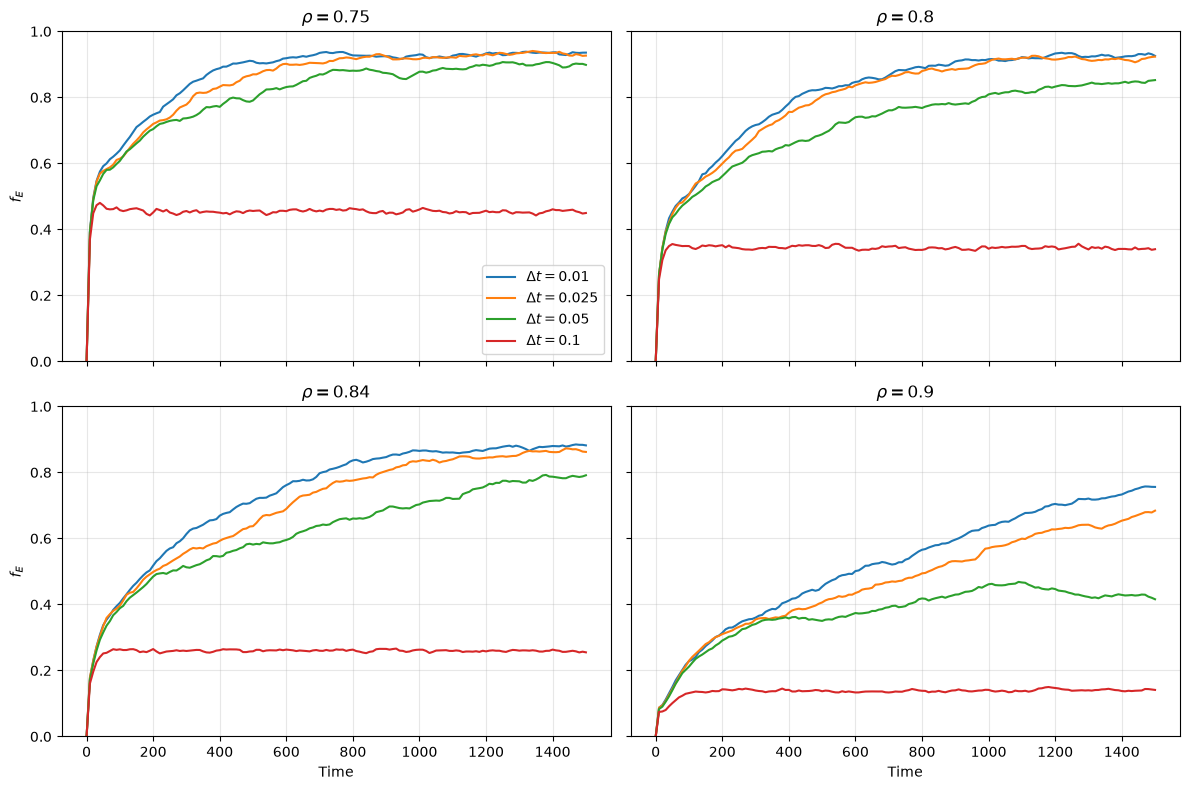

In [12]:
densities = sorted(order["rho"].unique())
delta_ts = sorted(order["delta_t"].unique())

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

for ax, rho in zip(axes.flat, densities):

    for delta_t in delta_ts:

        data = fraction_elongated_time[
            (fraction_elongated_time["rho"] == rho)
            & (fraction_elongated_time["delta_t"] == delta_t)
        ]

        ax.plot(
            data["time"],
            data["mean"],
            label=fr"$\Delta t={delta_t}$",
        )

    ax.set_title(fr"$\rho={rho}$")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time")

for ax in axes[:, 0]:
    ax.set_ylabel(r"$f_E$")

axes[0, 0].legend()

plt.tight_layout()
plt.show()

### Paired comparison between time steps

Since the same random seeds were used for all values of $\Delta t$, the simulations can be compared realization by realization.

For each density, seed, and physical time, we compute the difference

$$
\Delta f_E(t;\Delta t)
=
f_E(t;\Delta t)
-
f_E(t;0.01),
$$

using $\Delta t=0.01$ as the current reference.

A systematic deviation from zero indicates a numerical bias associated with the integration time step, while fluctuations around zero are more consistent with realization-to-realization variability.

In [13]:
reference_dt = 0.01

reference = (
    order[order["delta_t"] == reference_dt]
    [
        ["rho", "seed", "time", "fraction_elongated"]
    ]
    .rename(
        columns={
            "fraction_elongated": "fraction_elongated_reference"
        }
    )
)

In [14]:
paired_fraction = (
    order[order["delta_t"] != reference_dt]
    .merge(
        reference,
        on=["rho", "seed", "time"],
        how="inner",
        validate="many_to_one",
    )
)

paired_fraction["delta_fraction_elongated"] = (
    paired_fraction["fraction_elongated"]
    - paired_fraction["fraction_elongated_reference"]
)

In [15]:
paired_fraction[
    [
        "rho",
        "seed",
        "time",
        "delta_t",
        "fraction_elongated",
        "fraction_elongated_reference",
        "delta_fraction_elongated",
    ]
].head()

,rho,seed,time,delta_t,fraction_elongated,fraction_elongated_reference,delta_fraction_elongated
0,0.75,12944511869278,0.0,0.025,0.000,0.000,0.000
1,0.75,12944511869278,10.0,0.025,0.385,0.388,-0.003
2,0.75,12944511869278,20.0,0.025,0.465,0.489,-0.024
3,0.75,12944511869278,30.0,0.025,0.517,0.557,-0.040
4,0.75,12944511869278,40.0,0.025,0.533,0.590,-0.057


The paired differences are then averaged over realizations at each physical time.

If a given value of $\Delta t$ is numerically consistent with the reference, the mean paired difference should remain close to zero throughout the simulation.

In [16]:
paired_fraction_time = (
    paired_fraction
    .groupby(
        ["rho", "delta_t", "time"]
    )["delta_fraction_elongated"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

paired_fraction_time["sem"] = (
    paired_fraction_time["std"]
    / np.sqrt(paired_fraction_time["count"])
)

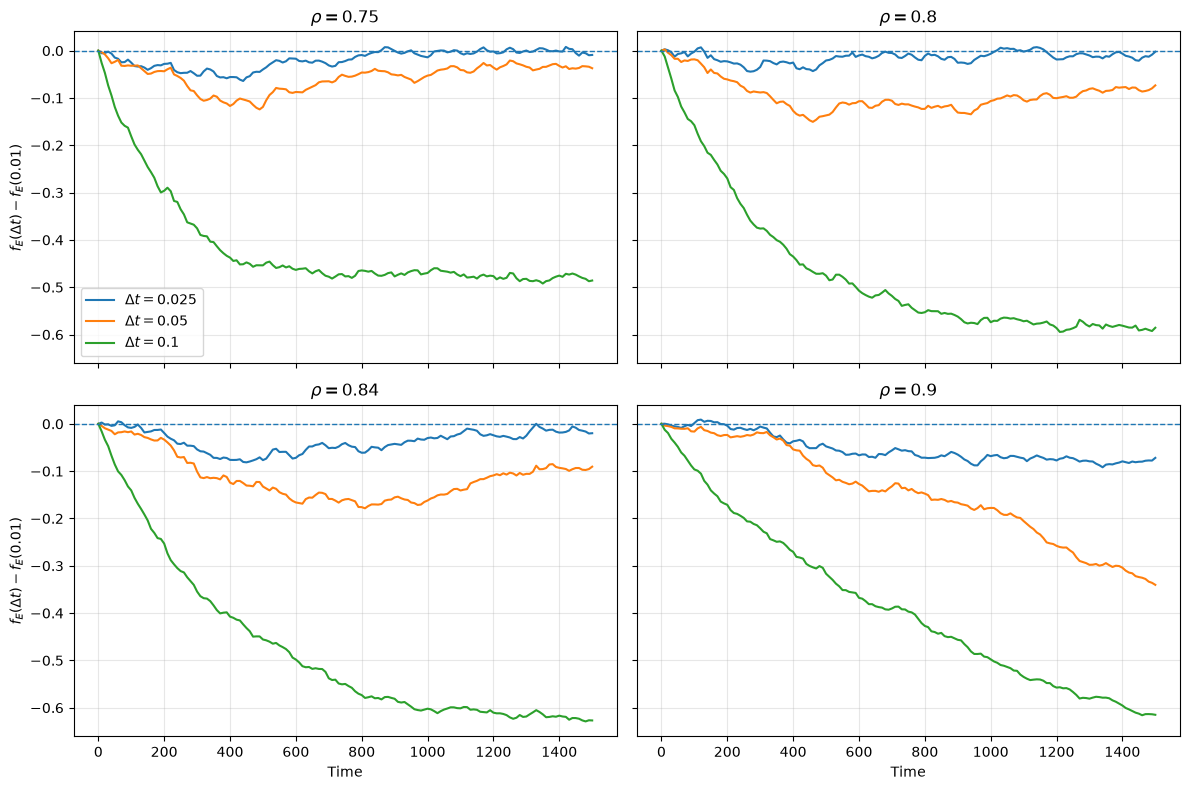

In [17]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
)

for ax, rho in zip(axes.flat, densities):

    for delta_t in sorted(
        paired_fraction_time["delta_t"].unique()
    ):

        data = paired_fraction_time[
            (paired_fraction_time["rho"] == rho)
            & (paired_fraction_time["delta_t"] == delta_t)
        ]

        ax.plot(
            data["time"],
            data["mean"],
            label=fr"$\Delta t={delta_t}$",
        )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(fr"$\rho={rho}$")
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel("Time")

for ax in axes[:, 0]:
    ax.set_ylabel(
        r"$f_E(\Delta t)-f_E(0.01)$"
    )

axes[0, 0].legend()

plt.tight_layout()
plt.show()

### Preliminary time-step dependence

The paired comparison shows a systematic dependence of the elongated-cell fraction on the integration time step.

Large time steps consistently produce smaller values of \(f_E\) than the current reference \(\Delta t=0.01\). The discrepancy is particularly strong for \(\Delta t=0.1\) and remains significant for \(\Delta t=0.05\).

The results for \(\Delta t=0.025\) are considerably closer to those obtained with \(\Delta t=0.01\), but systematic differences remain, particularly at high density.

Therefore, the present results are not sufficient to establish that \(\Delta t=0.01\) is itself within the converged regime. Additional simulations with smaller time steps are required.

### Representative final configurations

To complement the quantitative comparison of the elongated-cell fraction, we inspect representative final configurations at \(t=1500\).

For each density, a representative realization is selected using the smallest currently available time step as reference. The selected seed corresponds to the realization whose final elongated-cell fraction is closest to the median over all realizations.

The same seed is then shown for all values of \(\Delta t\), allowing differences in the final spatial organization to be associated with the integration time step rather than with realization-to-realization variability.

A separate figure is shown for each density.

In [18]:
reference_dt = 0.01
final_time = 1500

In [19]:
final_order_reference = order[
    (order["delta_t"] == reference_dt)
    & (order["time"] == final_time)
].copy()

representative_seeds = {}

for rho in densities:

    data = final_order_reference[
        final_order_reference["rho"] == rho
    ].copy()

    median_fraction = data["fraction_elongated"].median()

    index = (
        data["fraction_elongated"]
        - median_fraction
    ).abs().idxmin()

    representative_seeds[rho] = int(
        data.loc[index, "seed"]
    )

representative_seeds

{np.float64(0.75): 78804909138230,
 np.float64(0.8): 542029227742456,
 np.float64(0.84): 260045648084392,
 np.float64(0.9): 260045648084392}

In [20]:
# Orientation colors shared by every figure
hue = np.linspace(0, 1, 1024)

hsv_colors = np.column_stack([
    hue,
    np.full_like(hue, 0.75),
    np.full_like(hue, 0.90),
])

ORIENTATION_CMAP = ListedColormap(
    hsv_to_rgb(hsv_colors),
    name="orientation_hsv",
)

ORIENTATION_NORM = Normalize(0, 2 * np.pi)

ROUND_COLOR = "0.80"

In [21]:
@lru_cache(maxsize=64)
def read_snapshot(path):
    """Read positions, semi-axes, orientations, and box dimensions."""

    with path.open() as stream:
        number_of_cells = int(stream.readline())
        header = stream.readline()

        expected_schema = (
            "Properties=species:S:1:pos:R:3:"
            "aspherical_shape:R:3:"
            "orientation:R:4:"
            "Color:R:1"
        )

        if expected_schema not in header:
            raise ValueError(
                f"Unexpected OVITO schema: {path}"
            )

        lattice_match = re.search(
            r'Lattice="([^"]+)"',
            header,
        )

        if lattice_match is None:
            raise ValueError(
                f"Missing box dimensions in {path}"
            )

        lattice = np.fromstring(
            lattice_match.group(1),
            sep=" ",
        ).reshape(3, 3)

        values = np.loadtxt(
            stream,
            usecols=range(1, 12),
            ndmin=2,
        )

    if len(values) != number_of_cells:
        raise ValueError(
            f"Inconsistent cell count in {path}"
        )

    if not np.allclose(
        lattice,
        np.diag(np.diag(lattice)),
    ):
        raise ValueError(
            f"Only orthorhombic boxes are supported: {path}"
        )

    box = np.array([
        lattice[0, 0],
        lattice[1, 1],
    ])

    if (
        not np.all(box > 0)
        or not np.isfinite(values).all()
    ):
        raise ValueError(
            f"Invalid box or nonfinite snapshot data: {path}"
        )

    if np.any(values[:, 3:5] <= 0):
        raise ValueError(
            f"Invalid semi-axes: {path}"
        )

    # Planar rotations are stored as quaternions (x, y, z, w)
    phi = np.mod(
        2 * np.arctan2(
            values[:, 8],
            values[:, 9],
        ),
        2 * np.pi,
    )

    return {
        "positions": values[:, :2] % box,
        "major": values[:, 3],
        "minor": values[:, 4],
        "phi": phi,
        "box": box,
    }

In [22]:
def find_ovito_snapshot(
    directory,
    rho,
    seed,
):

    pattern = (
        f"*density={rho}"
        f"_force=*"
        f"_rng_seed={seed}.*"
    )

    files = list(directory.glob(pattern))

    if len(files) != 1:
        raise ValueError(
            f"Expected one OVITO file for "
            f"rho={rho}, seed={seed}, "
            f"found {len(files)}"
        )

    return files[0]

In [23]:
def draw_snapshot(
    ax,
    snapshot,
    annotation=None,
):
    """Draw one configuration, including periodic boundary copies."""

    positions = snapshot["positions"]
    major = snapshot["major"]
    minor = snapshot["minor"]
    phi = snapshot["phi"]
    box = snapshot["box"]

    is_round = np.isclose(
        major / minor,
        1.0,
    )

    colors = ORIENTATION_CMAP(
        ORIENTATION_NORM(phi)
    )

    colors[is_round] = (
        plt.matplotlib.colors.to_rgba(
            ROUND_COLOR
        )
    )

    # Bounding-box half-widths of each rotated ellipse
    extent_x = np.sqrt(
        (major * np.cos(phi))**2
        + (minor * np.sin(phi))**2
    )

    extent_y = np.sqrt(
        (major * np.sin(phi))**2
        + (minor * np.cos(phi))**2
    )

    for shift_x, shift_y in product(
        [-box[0], 0, box[0]],
        [-box[1], 0, box[1]],
    ):
        shifted = (
            positions
            + np.array([shift_x, shift_y])
        )

        visible = (
            (shifted[:, 0] + extent_x >= 0)
            & (shifted[:, 0] - extent_x <= box[0])
            & (shifted[:, 1] + extent_y >= 0)
            & (shifted[:, 1] - extent_y <= box[1])
        )

        if not visible.any():
            continue

        collection = EllipseCollection(
            widths=2 * major[visible],
            heights=2 * minor[visible],
            angles=np.degrees(phi[visible]),
            units="xy",
            offsets=shifted[visible],
            transOffset=ax.transData,
            facecolors=colors[visible],
            edgecolors="0.25",
            linewidths=0.20,
            rasterized=True,
        )

        ax.add_collection(collection)

    ax.set(
        xlim=(0, box[0]),
        ylim=(0, box[1]),
        aspect="equal",
        xticks=[],
        yticks=[],
    )

    if annotation is None:
        annotation = (
            rf"$f_E={np.mean(~is_round):.2f}$"
        )

    ax.text(
        0.03,
        0.97,
        annotation,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.8,
            "pad": 1.5,
        },
    )

In [24]:
def add_orientation_wheel(fig):
    """Add a circular legend using the same orientation mapping."""

    ax = fig.add_axes(
        [0.89, 0.88, 0.07, 0.07],
        projection="polar",
    )

    theta_edges = np.linspace(
        0,
        2 * np.pi,
        721,
    )

    theta_centers = (
        theta_edges[:-1]
        + theta_edges[1:]
    ) / 2

    ax.pcolormesh(
        theta_edges,
        [0, 1],
        theta_centers[None, :],
        cmap=ORIENTATION_CMAP,
        norm=ORIENTATION_NORM,
        shading="flat",
        rasterized=True,
    )

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    ax.set_xticks(
        [
            0,
            np.pi / 2,
            np.pi,
            3 * np.pi / 2,
        ],
        labels=[
            r"$0$",
            r"$\pi/2$",
            r"$\pi$",
            r"$3\pi/2$",
        ],
    )

    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.grid(False)

    ax.tick_params(
        axis="x",
        labelsize=8,
        pad=0,
    )

    ax.spines["polar"].set_linewidth(0.8)

In [25]:
def plot_density_comparison(
    rho,
    representative_seeds,
    ovito_dirs,
):
    """Compare final configurations for one density."""

    seed = representative_seeds[rho]

    delta_ts = sorted(
        ovito_dirs.keys()
    )

    ncols = min(3, len(delta_ts))
    nrows = int(
        np.ceil(len(delta_ts) / ncols)
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 4 * nrows),
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for ax, delta_t in zip(
        axes,
        delta_ts,
    ):
        filepath = find_ovito_snapshot(
            directory=ovito_dirs[delta_t],
            rho=rho,
            seed=seed,
        )

        snapshot = read_snapshot(
            filepath
        )

        draw_snapshot(
            ax,
            snapshot,
        )

        ax.set_title(
            fr"$\Delta t={delta_t:g}$"
        )

    # Hide unused axes
    for ax in axes[len(delta_ts):]:
        ax.set_visible(False)

    fig.suptitle(
        fr"$\rho={rho}$",
        fontsize=14,
    )

    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        bottom=0.04,
        top=0.90,
        wspace=0.08,
        hspace=0.15,
    )

    add_orientation_wheel(fig)

    plt.show()

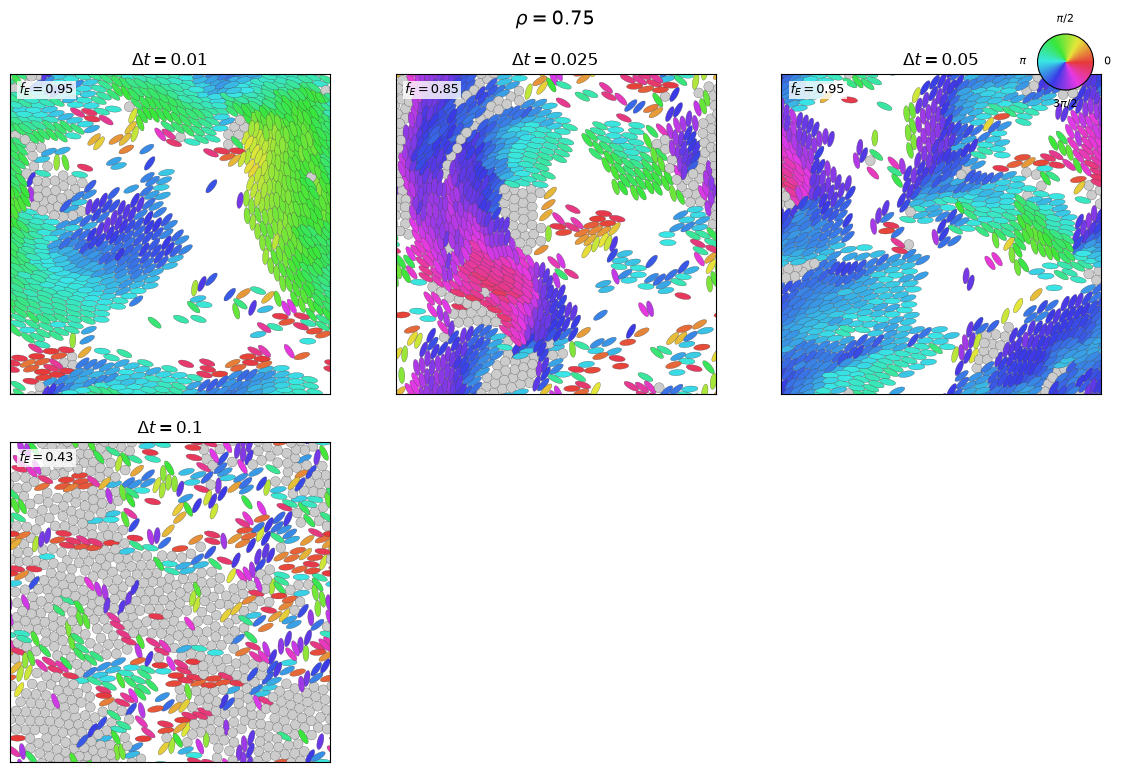

In [26]:
plot_density_comparison(
    rho=0.75,
    representative_seeds=representative_seeds,
    ovito_dirs=OVITO_DIRS,
)

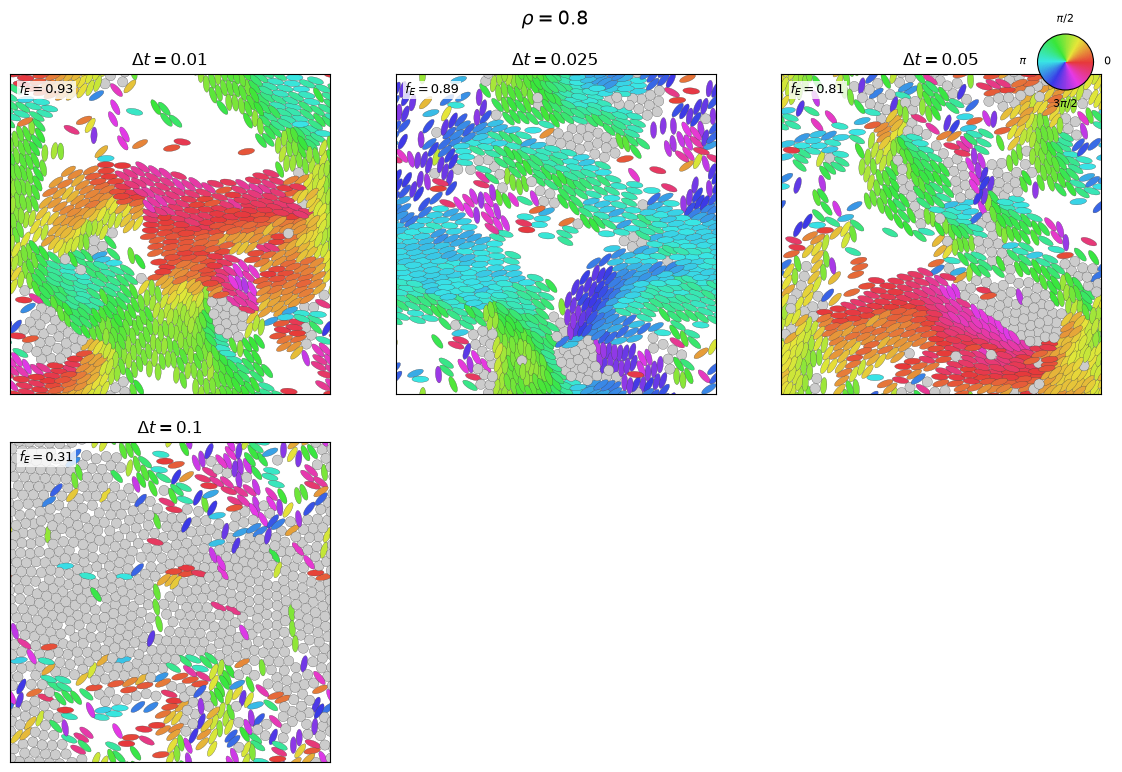

In [27]:
plot_density_comparison(
    rho=0.8,
    representative_seeds=representative_seeds,
    ovito_dirs=OVITO_DIRS,
)

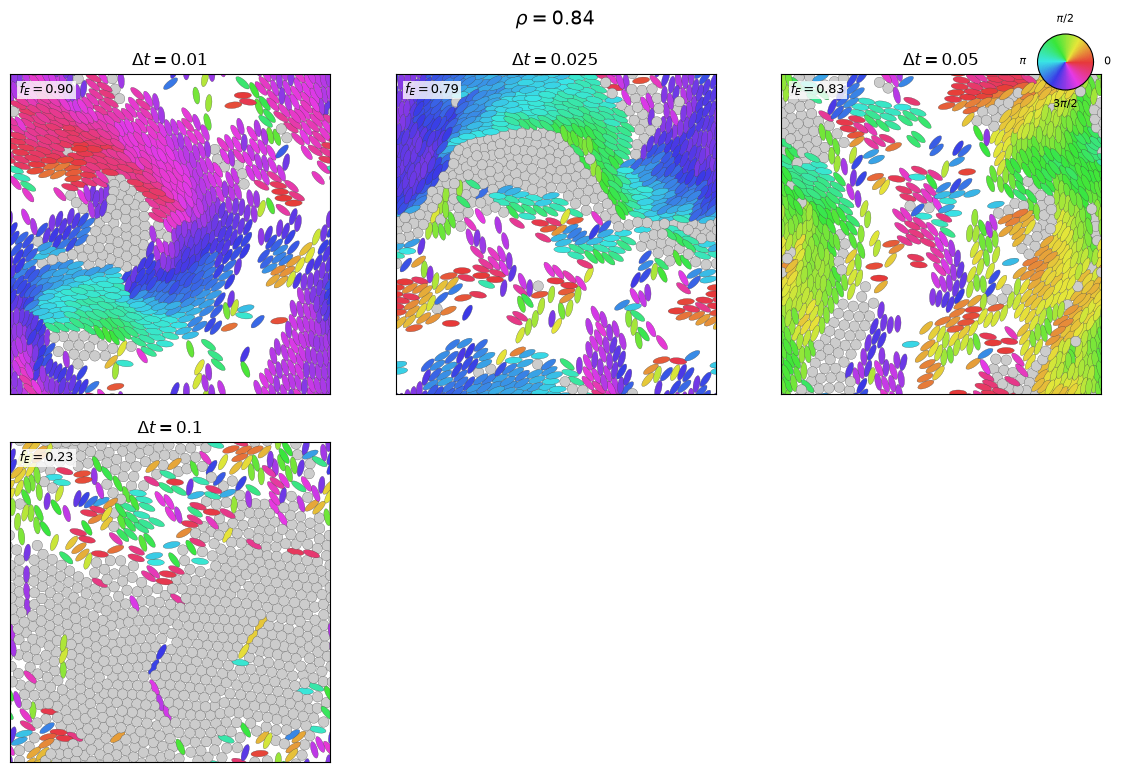

In [28]:
plot_density_comparison(
    rho=0.84,
    representative_seeds=representative_seeds,
    ovito_dirs=OVITO_DIRS,
)

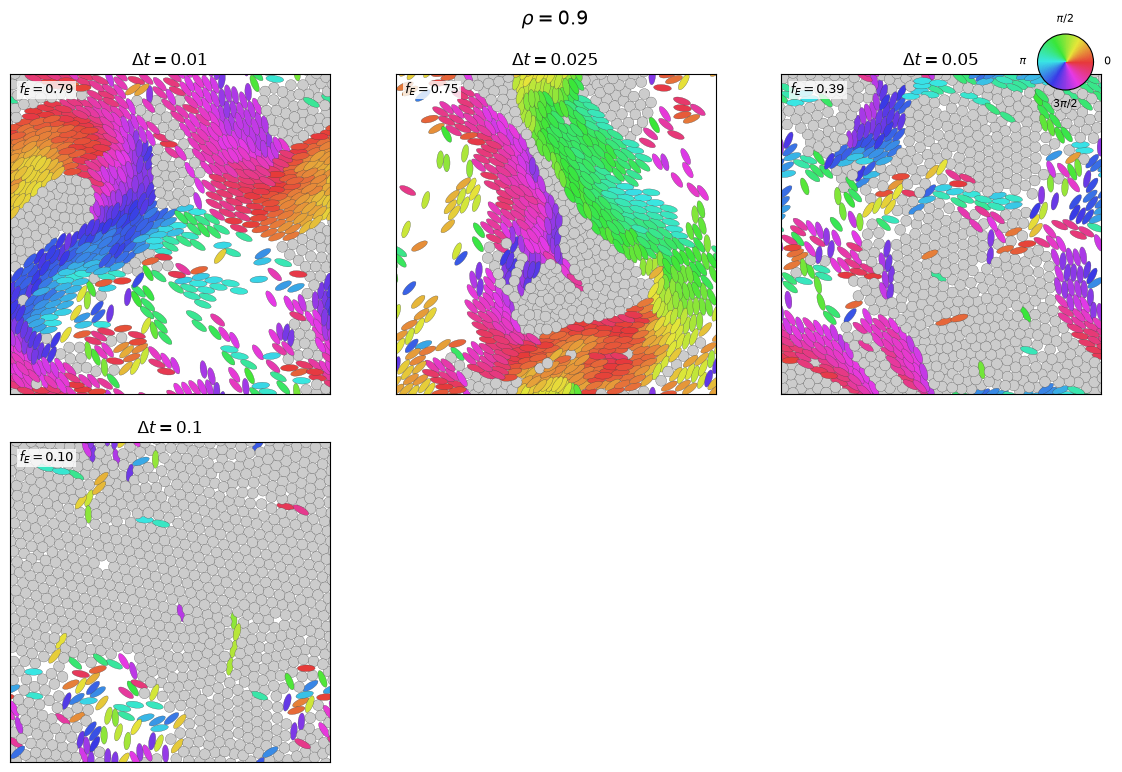

In [29]:
plot_density_comparison(
    rho=0.9,
    representative_seeds=representative_seeds,
    ovito_dirs=OVITO_DIRS,
)